# 06 · EDA — Balance hidrico (DMA)

`gold.balance_hidrico_baleares` — balance simplificado anual por masa (2015-2024): entradas/salidas, disponibilidad, explotacion y estado DMA. Contexto para interpretar el consumo (masas en riesgo).


In [1]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
DATA = Path("data")


In [2]:
df = pl.read_csv(DATA / "balance_hidrico_baleares.csv", infer_schema_length=None)
print("shape:", df.shape)
print("masas:", df["cod_masa"].n_unique())
df.head(5)


shape: (730, 21)
masas: 74


cod_masa,anio,infiltracion_lluvia_hm3,infiltracion_torrentes_hm3,retorno_riegos_hm3,perdida_redes_abastecimiento_hm3,perdida_redes_alcantarillado_hm3,intrusion_salina_hm3,suma_entradas_hm3,diferencia_vs_rp_hm3,abastecimiento_urbano_hm3,torrentes_hm3,manantiales_hm3,humedales_hm3,salida_mar_hm3,salida_zzhh_hm3,suma_salidas_hm3,disponibilidad_hm3,extraccion_hm3,explotacion_porcentaje,estado_cuantitativo
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""1815M4""",2021,3.774,0.032,0.277,0.12,0.073,0.0,4.276,-0.615,0.403,0.702,0.0,0.0,0.0,0.0,1.105,4.276,0.403,0.094,"""buen_estado"""
"""1819M1""",2015,3.983,0.0,0.089,1.281,0.189,0.084,5.626,-1.004,2.294,0.133,0.216,0.0,0.19,0.0,2.833,5.352,2.294,0.429,"""buen_estado"""
"""1819M1""",2017,4.637,0.0,0.089,1.281,0.189,0.084,6.28,-0.35,2.337,0.155,0.251,0.0,0.19,0.0,2.933,6.006,2.337,0.389,"""buen_estado"""
"""1817M1""",2024,3.409,0.097,0.119,0.931,0.281,0.18,5.017,-1.538,2.461,0.517,0.101,0.056,1.683,0.028,4.846,3.126,2.461,0.787,"""buen_estado"""
"""1814M1""",2018,12.822,0.547,0.037,1.208,0.339,0.0,14.953,1.62,2.551,1.096,0.0,0.0,3.112,0.0,6.759,11.841,2.551,0.215,"""buen_estado"""


In [3]:
print("Nulos por columna:")
df.null_count()


Nulos por columna:


cod_masa,anio,infiltracion_lluvia_hm3,infiltracion_torrentes_hm3,retorno_riegos_hm3,perdida_redes_abastecimiento_hm3,perdida_redes_alcantarillado_hm3,intrusion_salina_hm3,suma_entradas_hm3,diferencia_vs_rp_hm3,abastecimiento_urbano_hm3,torrentes_hm3,manantiales_hm3,humedales_hm3,salida_mar_hm3,salida_zzhh_hm3,suma_salidas_hm3,disponibilidad_hm3,extraccion_hm3,explotacion_porcentaje,estado_cuantitativo
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,54,0


In [4]:
# Cobertura: masas sin balance (5 sin recurso potencial)
cov = df.group_by("cod_masa").agg(n=pl.len()).sort("n")
print("masas sin balance:", (cov["n"] == 0).sum())
print("anios con balance:", sorted(df["anio"].unique().to_list()))


masas sin balance: 0
anios con balance: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


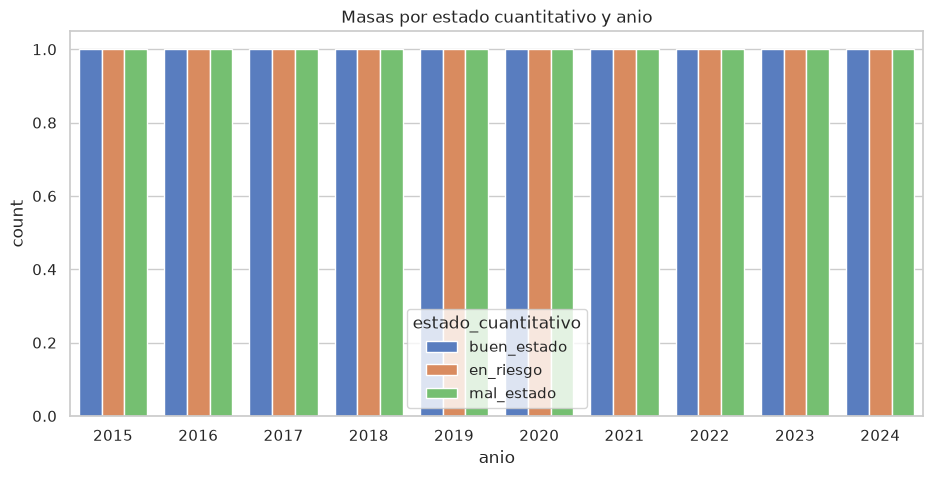

In [5]:
# Estado cuantitativo DMA por anio
import matplotlib.ticker as mticker
est = df.group_by(["anio", "estado_cuantitativo"]).len()
sns.countplot(data=est.to_pandas(), x="anio", hue="estado_cuantitativo",
              order=sorted(est["anio"].unique().to_list()))
plt.title("Masas por estado cuantitativo y anio")
plt.show()


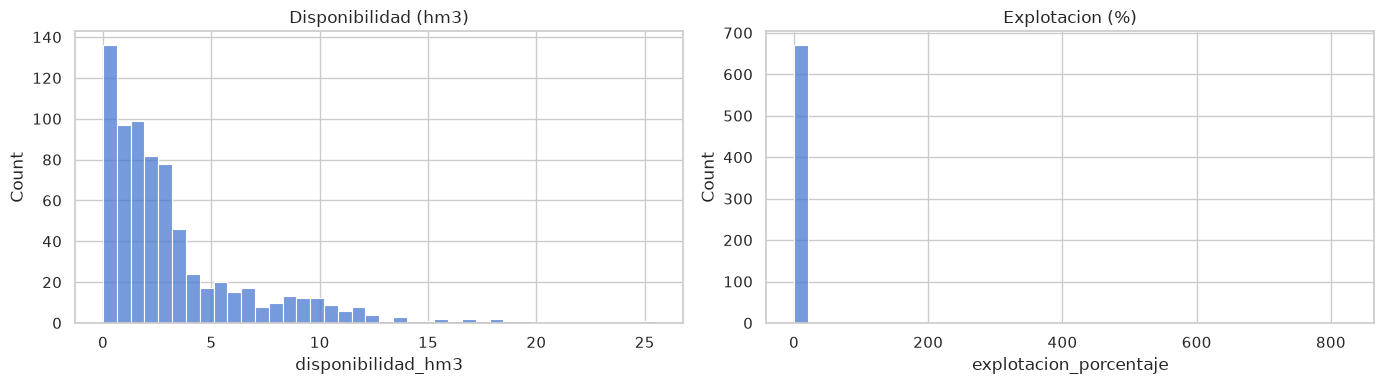

filas en deficit: 113 | masas distintas: 26


anio,len
i64,u32
2015,15
2016,11
2017,12
2018,6
2019,14
2020,12
2021,4
2022,13
2023,12


In [6]:
# Distribuciones de disponibilidad y explotacion
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["disponibilidad_hm3"].to_pandas(), bins=40, ax=axes[0])
axes[0].set_title("Disponibilidad (hm3)")
sns.histplot(df["explotacion_porcentaje"].to_pandas(), bins=40, ax=axes[1])
axes[1].set_title("Explotacion (%)")
plt.tight_layout()
plt.show()

# Masas en deficit (explotacion > 100%)
deficit = df.filter(pl.col("explotacion_porcentaje") > 1)
print("filas en deficit:", deficit.height, "| masas distintas:", deficit["cod_masa"].n_unique())
deficit.group_by("anio").len().sort("anio")


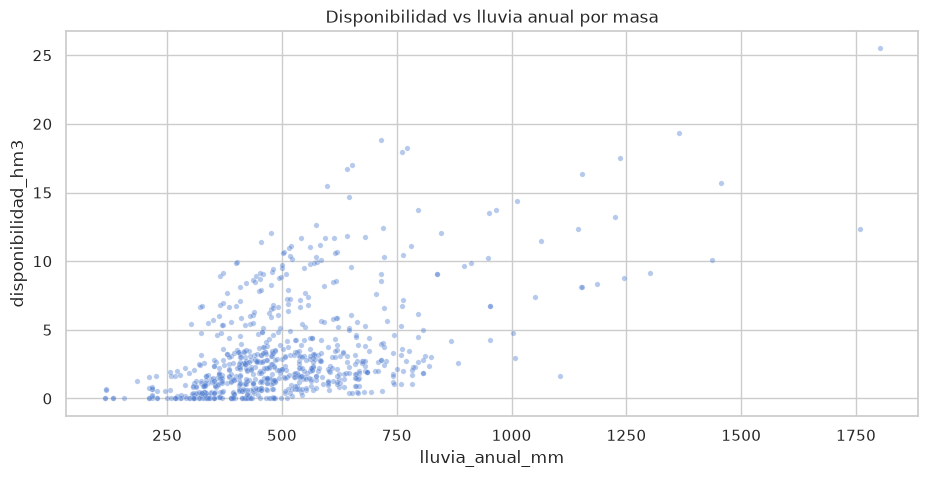

In [7]:
# Relacion disponibilidad vs lluvia anual (masa x anio)
ll = pl.read_csv(DATA / "lluvia_masa_subterranea.csv", infer_schema_length=None)
ll_anual = ll.group_by(["cod_masa", "anio"]).agg(pl.col("precipitacion_mm").sum().alias("lluvia_anual_mm"))
cmp = df.select(["cod_masa", "anio", "disponibilidad_hm3"]).join(ll_anual, on=["cod_masa", "anio"], how="inner")
sns.scatterplot(data=cmp.to_pandas(), x="lluvia_anual_mm", y="disponibilidad_hm3", alpha=0.4, s=15)
plt.title("Disponibilidad vs lluvia anual por masa")
plt.show()


**Conclusiones EDA**

- 730 filas: 82 masas con recurso potencial x 10 anios (2015-2024); 5 masas sin RP no tienen balance.
- El numero de masas en mal estado/riesgo varia con el anio hidrologico (lluvia -> disponibilidad).
- El balance sirve de **contexto** (masas en deficit) para el modelado de consumo; no es feature directa en v1.
